# Analisis Kualitas Polutan CO Kec. Labang, Kab. Bangkalan


## 0. Ringkasan

1. **Cakupan wilayah** — bukan lagi seluruh Kabupaten Bangkalan (seperti tugas sebelumnya), tetapi **satu kecamatan sesuai kecamatan masing-masing mahasiswa**. Untuk kasus saya: **Kecamatan Labang**
2. **Rentang waktu** — data diambil dari **31 Agustus 2025 sampai 31 Agustus 2026**.
3. **Alur wajib** — data mentah → **deteksi outlier** → **imputasi missing value** → jika data sudah bersih (tidak ada outlier & missing) → **ekstraksi fitur TSFEL sebanyak 68 fitur**

## 1. Business Understanding

### 1.1 Latar belakang

Karbon monoksida (**CO**) adalah gas pencemar udara yang tidak berwarna dan tidak berbau. CO terutama terbentuk dari pembakaran bahan bakar yang tidak sempurna, misalnya dari kendaraan bermotor, aktivitas pembakaran, dan berbagai proses pembakaran lainnya. Karena CO dapat memengaruhi kualitas udara dan berinteraksi dengan kondisi atmosfer, pemantauan pola CO dari waktu ke waktu penting untuk memahami dinamika pencemaran di suatu wilayah.

Kecamatan Labang dipilih dengan batas administratif yang direpresentasikan melalui file `Kecamatan_Labang.geojson`.

### 1.2 Tujuan proyek

1. Mengambil data CO harian di Kecamatan Labang selama periode 31 Agustus 2025 – 31 Agustus 2026 dari Sentinel-5P (openEO/Copernicus Data Space).
2. Membersihkan data (deteksi outlier + imputasi missing value) sehingga sinyal time series valid untuk diproses lebih lanjut.
3. Meringkas pola time series CO menjadi **68 fitur numerik** menggunakan pustaka **TSFEL** (Time Series Feature Extraction Library).
4. Memverifikasi sebagian fitur dengan **perhitungan manual** berdasarkan rumus statistik, temporal, dan spectral yang relevan.

### 1.3 Pertanyaan analisis

> Bagaimana karakteristik statistik, perubahan temporal, energi, bentuk distribusi, dan pola frekuensi dari time series CO Kecamatan Labang selama satu tahun penuh, jika diringkas menggunakan 68 fitur TSFEL?

### 1.4 Kriteria keberhasilan (Definition of Done)

| No | Kriteria | Target |
|---|---|---|
| 1 | Cakupan wilayah | sesuai polygon `Kecamatan_Labang.geojson` |
| 2 | Cakupan waktu | 31-08-2025 s.d. 31-08-2026 |
| 3 | Missing value setelah imputasi | 0 |
| 4 | Outlier setelah penanganan | ditandai & diimputasi, tidak ada nilai ekstrem tersisa |
| 5 | Jumlah fitur output | tepat 68 |
| 6 | Verifikasi manual | fitur dasar dibandingkan dengan rumus manual |
| 7 | File CSV final | tidak dimodifikasi setelah dihasilkan |


## 2. Data Understanding

### 2.1 Sumber data

Data bersumber dari **Sentinel-5P TROPOMI Level-2**, diakses melalui **openEO Copernicus Data Space Ecosystem** (`openeo.dataspace.copernicus.eu`). Koleksi yang dipanggil adalah `SENTINEL_5P_L2` dengan band **`CO`**.

Nilai CO dari produk satelit merupakan **pengukuran kolom atmosfer** sesuai definisi produk Sentinel-5P/TROPOMI, sehingga satuan dan makna fisiknya harus mengikuti metadata produk yang digunakan. Nilai tersebut tidak boleh langsung dianggap sebagai konsentrasi udara permukaan dalam µg/m³ tanpa konversi/model tambahan. Catatan ini penting agar hasil statistik tidak salah diinterpretasikan.

### 2.2 Wilayah kajian (AOI) — GeoJSON Kecamatan Labang

File `Kecamatan_Labang.geojson` berisi **2 feature**:

1. **Titik pusat** (`Point`) Kecamatan Labang pada koordinat **(112.80314, -7.157302)**.
2. **Polygon** batas administratif dengan 5 titik koordinat (titik pertama = titik terakhir, menutup polygon):

| Titik | Longitude | Latitude |
|---|---|---|
| 1 | 112.764412 | -7.164744 |
| 2 | 112.822778 | -7.164744 |
| 3 | 112.822778 | -7.110860 |
| 4 | 112.764412 | -7.110860 |
| 5 (=1) | 112.764412 | -7.164744 |

### 2.3 Variabel time series

| Kolom | Tipe | Keterangan |
|---|---|---|
| `date` | datetime (harian) | tanggal observasi agregat |
| `CO` | float | rata-rata spasial CO di dalam polygon Labang pada tanggal tersebut |

### 2.4 Periode data & ekspektasi jumlah observasi

Rentang **31 Agustus 2025 → 31 Agustus 2026** bersifat **inklusif** pada kedua ujungnya. Periode satu tahun kalender tersebut menghasilkan **366 tanggal** ketika kedua tanggal batas ikut dihitung.

### 2.5 Potensi masalah kualitas data

Data satelit seperti Sentinel-5P dapat memiliki:

- **Missing value** — misalnya akibat kualitas retrieval, tutupan awan, validitas piksel, atau tidak tersedianya observasi yang valid pada hari tertentu di AOI.
- **Outlier** — nilai ekstrem yang dapat muncul akibat kondisi atmosfer yang tidak biasa, kualitas retrieval, atau karakteristik observasi.
- **Perbedaan cakupan harian** — tidak setiap tanggal selalu mempunyai jumlah piksel/observasi valid yang sama.

Karena tugas menggunakan time series harian penuh, tanggal yang tidak tersedia tetap dipertahankan sebagai tanggal kalender dan diperlakukan sebagai missing.


## 3. Data Preparation

Tahap ini mencakup: instalasi pustaka → pembacaan GeoJSON → pengambilan data Sentinel-5P → konversi ke CSV mentah → pemeriksaan kualitas awal → deteksi outlier (IQR) → pembuatan kalender harian penuh → imputasi missing/outlier → validasi akhir.

### 3.1 Instalasi pustaka


In [1]:
!pip -q install openeo netCDF4 tsfel psycopg2-binary

import os
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6g}")
print("Semua library utama berhasil di-import.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.0 MB/s eta 0:00:00
Semua library utama berhasil di-import.


### 3.2 Upload file GeoJSON Kecamatan Labang
pilih file `Kecamatan_Labang.geojson`

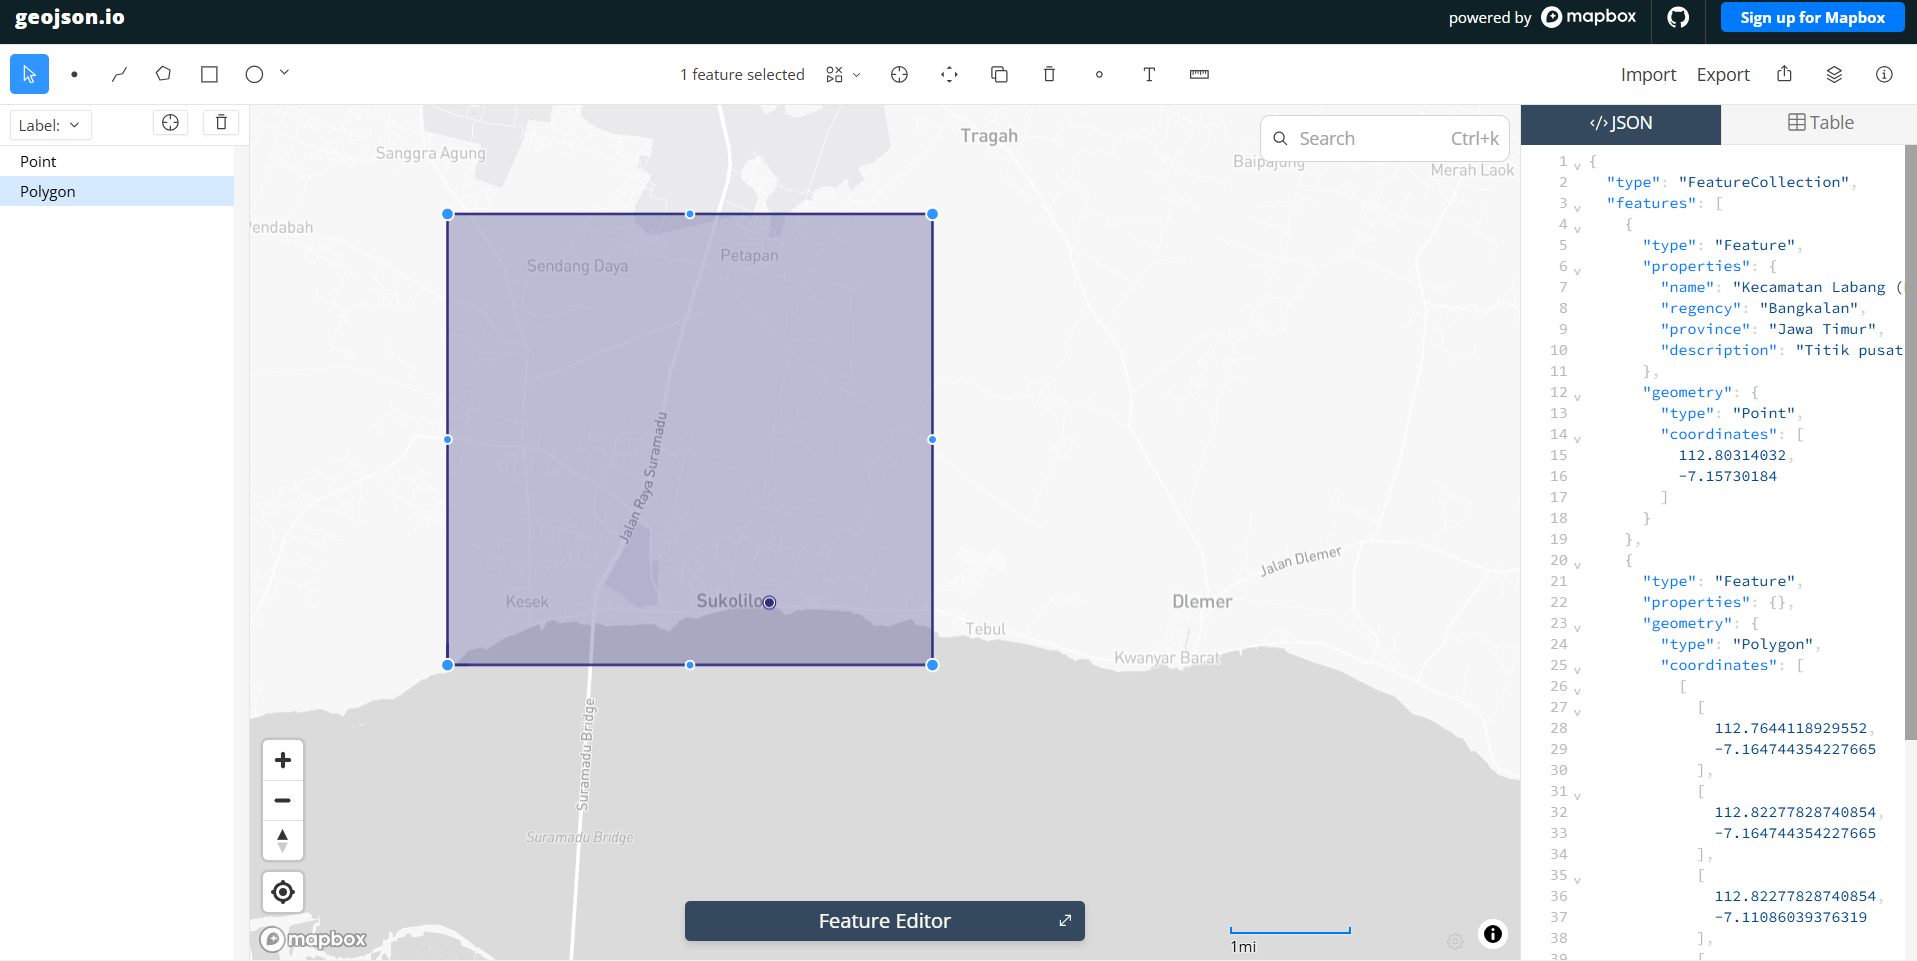

In [2]:
from google.colab import files

uploaded = files.upload()

geojson_candidates = [f for f in uploaded.keys() if f.lower().endswith(".geojson")]
if not geojson_candidates:
    raise FileNotFoundError("Belum ada file GeoJSON yang diunggah. Ulangi upload file Kecamatan_Labang.geojson.")

GEOJSON_PATH = geojson_candidates[0]
print("File GeoJSON yang digunakan:", GEOJSON_PATH)

Saving Kecamatan Labang.geojson to Kecamatan Labang.geojson
File GeoJSON yang digunakan: Kecamatan Labang.geojson


### 3.3 Membaca isi GeoJSON


In [3]:
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    labang_geojson = json.load(f)

print("Tipe FeatureCollection :", labang_geojson.get("type"))
print("Jumlah feature         :", len(labang_geojson.get("features", [])))
print()

for i, feature in enumerate(labang_geojson.get("features", [])):
    geom = feature.get("geometry", {})
    print(f"Feature {i}: tipe geometri = {geom.get('type')}, properti = {feature.get('properties', {})}")

Tipe FeatureCollection : FeatureCollection
Jumlah feature         : 2

Feature 0: tipe geometri = Point, properti = {'name': 'Kecamatan Labang (Pusat)', 'regency': 'Bangkalan', 'province': 'Jawa Timur', 'description': 'Titik pusat koordinat Kecamatan Labang'}
Feature 1: tipe geometri = Polygon, properti = {}


### 3.4 Mengambil polygon & menghitung bounding box (AOI)

Bounding box (kotak pembatas) dibutuhkan oleh openEO sebagai parameter `spatial_extent` (`west`, `south`, `east`, `north`). Untuk poligon dengan titik-titik $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, *bounding box* dihitung dengan:

$$\text{west} = \min(x_1, x_2, \dots, x_n), \qquad \text{east} = \max(x_1, x_2, \dots, x_n)$$
$$\text{south} = \min(y_1, y_2, \dots, y_n), \qquad \text{north} = \max(y_1, y_2, \dots, y_n)$$

di mana $x_i$ adalah bujur (longitude) dan $y_i$ adalah lintang (latitude) titik ke-$i$ pada poligon.

In [4]:
polygon_features = [
    feature for feature in labang_geojson.get("features", [])
    if feature.get("geometry", {}).get("type") == "Polygon"
]

if not polygon_features:
    raise ValueError("GeoJSON tidak memiliki geometry bertipe Polygon.")

aoi = polygon_features[0]["geometry"]
ring = aoi["coordinates"][0]

longitudes = [p[0] for p in ring]
latitudes = [p[1] for p in ring]

west = min(longitudes)
east = max(longitudes)
south = min(latitudes)
north = max(latitudes)

print("Titik-titik polygon (longitude, latitude):")
for i, p in enumerate(ring):
    print(f"  Titik {i+1}: ({p[0]}, {p[1]})")

print()
print("Bounding box AOI Kecamatan Labang:")
print("west  (min longitude) =", west)
print("east  (max longitude) =", east)
print("south (min latitude)  =", south)
print("north (max latitude)  =", north)

Titik-titik polygon (longitude, latitude):
  Titik 1: (112.764412, -7.164744)
  Titik 2: (112.822778, -7.164744)
  Titik 3: (112.822778, -7.11086)
  Titik 4: (112.764412, -7.11086)
  Titik 5: (112.764412, -7.164744)

Bounding box AOI Kecamatan Labang:
west  (min longitude) = 112.764412
east  (max longitude) = 112.822778
south (min latitude)  = -7.164744
north (max latitude)  = -7.11086



### 3.5 Pengambilan data Sentinel-5P CO via openEO

Langkah-langkah pada openEO:

1. `openeo.connect(...).authenticate_oidc()` — autentikasi ke Copernicus Data Space.
2. `load_collection("SENTINEL_5P_L2", ...)` — memuat koleksi TROPOMI dengan filter waktu & ruang serta memilih band `CO`.
3. `aggregate_temporal_period(reducer="mean", period="day")` — meringkas beberapa observasi dalam satu hari menjadi **satu nilai rata-rata harian**.
4. `aggregate_spatial(reducer="mean", geometries=aoi)` — meringkas seluruh piksel di dalam polygon Labang menjadi **satu nilai rata-rata spasial** per hari.
5. `execute_batch(...)` — menjalankan proses di server openEO dan mengunduh hasilnya sebagai file NetCDF (`.nc`).


In [5]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=WQTM-TEXN 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.


In [6]:
s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": west,
        "south": south,
        "east": east,
        "north": north
    },
    bands=["CO"]
)

# Agregasi temporal
s5p_CO_daily = s5CO.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Process graph CO Kecamatan Labang berhasil disusun.")

Process graph CO Kecamatan Labang berhasil disusun.


In [7]:
job_CO = s5p_CO_aoi.execute_batch(
    title="CO Kecamatan Labang 2025-08-31 sampai 2026-08-31",
    outputfile="CO_Labang.nc"
)

print("Batch job dikirim ke server openEO:")
print(job_CO)

0:00:00 Job 'j-2609200839394aab8b434668e85b54cc': send 'start'
0:00:03 Job 'j-2609200839394aab8b434668e85b54cc': created (progress 0%)
0:00:09 Job 'j-2609200839394aab8b434668e85b54cc': queued (progress 0%)
0:00:15 Job 'j-2609200839394aab8b434668e85b54cc': queued (progress 0%)
0:00:23 Job 'j-2609200839394aab8b434668e85b54cc': queued (progress 0%)
0:00:33 Job 'j-2609200839394aab8b434668e85b54cc': queued (progress 0%)
0:00:46 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:01:01 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:01:21 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:01:45 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:02:15 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:02:53 Job 'j-2609200839394aab8b434668e85b54cc': running (progress N/A)
0:03:40 Job 'j-2609200839394aab8b434668e85b54cc': finished (progress 100%)
Batch job dikirim ke server openEO:
<BatchJob job_id='j-260920083939

### 3.6 Konversi NetCDF menjadi time series CSV (data mentah / *raw*)

File NetCDF (`.nc`) adalah format data multidimensi (waktu × nilai). Kita ekstrak dua variabel:

- `t` — waktu (dalam satuan numerik + `units`, misalnya *"days since 2025-08-31"*), dikonversi ke tanggal kalender menggunakan `netCDF4.num2date()`.
- `CO` — nilai konsentrasi CO hasil agregasi harian & spasial.

Hasil disusun menjadi tabel `date, CO` dan disimpan sebagai `CO_Labang_raw.csv` — **file ini adalah data mentah, sebelum ada pembersihan apa pun**.

In [8]:
import netCDF4

dsCO = netCDF4.Dataset("CO_Labang.nc")

print("Variabel yang tersedia dalam file NetCDF:")
print(list(dsCO.variables.keys()))

Variabel yang tersedia dalam file NetCDF:
['t', 'CO', 'lat', 'lon', 'feature_names']


In [9]:
co = dsCO.variables["CO"][:].squeeze()
timeCO = dsCO.variables["t"][:]

try:
    time_units = dsCO.variables["t"].units
    dates = netCDF4.num2date(timeCO, units=time_units)
except Exception:
    dates = timeCO

new_dates = [dates[i].strftime("%Y-%m-%d") for i in range(len(dates))]

dfCO = pd.DataFrame({
    "date": new_dates,
    "CO": co
})

dfCO["date"] = pd.to_datetime(dfCO["date"])
dfCO = dfCO.sort_values("date").reset_index(drop=True)

dfCO.to_csv("CO_Labang_raw.csv", index=False)

print("File data mentah tersimpan: CO_Labang_raw.csv")
print("Jumlah baris (observasi mentah):", len(dfCO))
display(dfCO.head())
display(dfCO.tail())

File data mentah tersimpan: CO_Labang_raw.csv
Jumlah baris (observasi mentah): 203


,date,CO
0,2025-08-31,0.0275496
1,2025-09-01,0.0236686
2,2025-09-02,0.0256338
3,2025-09-03,0.0220901
4,2025-09-04,0.026039


,date,CO
198,2026-08-26,0.0305507
199,2026-08-27,0.0281181
200,2026-08-28,0.0357047
201,2026-08-29,0.0365699
202,2026-08-30,0.0335374


### 3.7 Mengunduh data mentah (belum dibersihkan)

data mentah `CO_Labang_raw.csv` **diunduh terlebih dahulu** sebagai bukti/arsip sebelum proses cleaning dilakukan. Ini penting untuk transparansi: siapa pun dapat membandingkan data sebelum dan sesudah pembersihan.


In [10]:
from google.colab import files as colab_files

colab_files.download("CO_Labang_raw.csv")
print("Unduhan dimulai: CO_Labang_raw.csv (data mentah, sebelum dibersihkan).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: CO_Labang_raw.csv (data mentah, sebelum dibersihkan).


### 3.8 Pemeriksaan kualitas data awal

Yang diperiksa pada tahap ini:

- struktur & tipe data;
- jumlah observasi & rentang tanggal;
- duplikasi tanggal;
- jumlah *missing value* (`NaN`);
- nilai tak-hingga (`+inf` / `-inf`);
- statistik deskriptif dasar.

**Rumus statistik dasar**

$$
\text{Mean } (\bar{x}) = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

$$
\text{Median} =
\begin{cases}
x_{(n+1)/2} & \text{jika } n \text{ ganjil} \\[4pt]
\dfrac{x_{n/2} + x_{n/2+1}}{2} & \text{jika } n \text{ genap}
\end{cases}
\quad \text{(urut data naik terlebih dahulu)}
$$

$$
\text{Variance sampel } (s^2) = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2
\qquad
\text{Standar deviasi } (s) = \sqrt{s^2}
$$


In [11]:
print("STRUKTUR DATA")
dfCO.info()

print("\nJUMLAH BARIS")
print(len(dfCO))

print("\nRENTANG TANGGAL")
print(dfCO["date"].min(), "sampai", dfCO["date"].max())

print("\nDUPLIKASI TANGGAL")
print(dfCO["date"].duplicated().sum())

dfCO["CO"] = pd.to_numeric(dfCO["CO"], errors="coerce")

print("\nJUMLAH MISSING VALUE")
print(dfCO["CO"].isna().sum())

print("\nNILAI TAK-HINGGA")
print("Positive infinity:", np.isposinf(dfCO["CO"]).sum())
print("Negative infinity:", np.isneginf(dfCO["CO"]).sum())

print("\nSTATISTIK DESKRIPTIF (pandas)")
print(dfCO["CO"].describe())

STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    203 non-null    datetime64[ns]
 1   CO      203 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB

JUMLAH BARIS
203

RENTANG TANGGAL
2025-08-31 00:00:00 sampai 2026-08-30 00:00:00

DUPLIKASI TANGGAL
0

JUMLAH MISSING VALUE
0

NILAI TAK-HINGGA
Positive infinity: 0
Negative infinity: 0

STATISTIK DESKRIPTIF (pandas)
count          203
mean     0.0286279
std     0.00387477
min      0.0159348
25%      0.0260938
50%      0.0287582
75%      0.0306626
max      0.0476724
Name: CO, dtype: float64



### Bukti manual pemeriksaan data CO
Pemeriksaan awal tidak hanya mengandalkan `pandas`. Secara manual, total sampel dihitung sebagai:

$$n = \sum_{i=1}^{N} 1$$

**Keterangan Rumus:**
* $N$: total keseluruhan baris/titik data yang diidentifikasi.
* $n$: jumlah sampel yang dihitung secara akurat.
* $x_i$: nilai observasi pada indeks baris ke-$i$.
* $I(\cdot)$: fungsi indikator yang bernilai $1$ jika kondisi di dalam kurung terpenuhi, dan bernilai $0$ jika tidak.


In [12]:
values = dfCO["CO"].tolist()
n_total_manual = len(values)
n_missing_manual = sum(1 for v in values if pd.isna(v))
n_posinf_manual = sum(1 for v in values if isinstance(v, (int,float,np.number)) and np.isposinf(v))
n_neginf_manual = sum(1 for v in values if isinstance(v, (int,float,np.number)) and np.isneginf(v))

print("Jumlah baris manual       :", n_total_manual)
print("Missing manual            :", n_missing_manual)
print("+Infinity manual          :", n_posinf_manual)
print("-Infinity manual          :", n_neginf_manual)
print("Tanggal minimum manual    :", min(dfCO["date"]))
print("Tanggal maksimum manual   :", max(dfCO["date"]))
print()
print("Verifikasi terhadap pandas:")
print("Baris sama?    ", n_total_manual == len(dfCO))
print("Missing sama?  ", n_missing_manual == int(dfCO["CO"].isna().sum()))


Jumlah baris manual       : 203
Missing manual            : 0
+Infinity manual          : 0
-Infinity manual          : 0
Tanggal minimum manual    : 2025-08-31 00:00:00
Tanggal maksimum manual   : 2026-08-30 00:00:00

Verifikasi terhadap pandas:
Baris sama?     True
Missing sama?   True


### 3.9 Perhitungan manual statistik dasar

Menghitung mean, median, variance, dan standar deviasi **langkah demi langkah menggunakan perulangan (loop) murni Python**, lalu membandingkan hasilnya dengan fungsi bawaan pandas untuk memverifikasi bahwa rumus manual memberi hasil yang identik (selisih ≈ 0, hanya berbeda karena pembulatan floating point).


In [13]:
valid = dfCO["CO"].dropna().astype(float).tolist()
n = len(valid)

if n == 0:
    raise ValueError("Kolom CO tidak memiliki nilai valid sama sekali.")

# Mean manual: x_bar = (sum xi) / n
sum_x = 0.0
for x in valid:
    sum_x += x
mean_manual = sum_x / n

# Median manual: urutkan dahulu, lalu ambil nilai tengah
urut = sorted(valid)
if n % 2 == 1:
    median_manual = urut[n // 2]
else:
    median_manual = (urut[n // 2 - 1] + urut[n // 2]) / 2

# Variance sampel manual: s^2 = sum((xi - x_bar)^2) / (n - 1)
sum_sq = 0.0
for x in valid:
    sum_sq += (x - mean_manual) ** 2
variance_manual = sum_sq / (n - 1) if n > 1 else np.nan
std_manual = np.sqrt(variance_manual) if n > 1 else np.nan

print(f"n (jumlah data valid)      = {n}")
print(f"Sigma x (total)            = {sum_x:.6g}")
print(f"Mean manual (x_bar)        = {mean_manual:.6g}")
print(f"Median manual              = {median_manual:.6g}")
print(f"Nilai minimum              = {urut[0]:.6g}")
print(f"Nilai maksimum             = {urut[-1]:.6g}")
print(f"Sigma (xi - x_bar)^2       = {sum_sq:.6g}")
print(f"Variance sampel manual s^2 = {variance_manual:.6g}")
print(f"Standar deviasi manual s   = {std_manual:.6g}")

print("\nVerifikasi dengan pandas")
print(f"Mean (pandas)     = {dfCO['CO'].mean():.6g}")
print(f"Median (pandas)   = {dfCO['CO'].median():.6g}")
print(f"Min (pandas)      = {dfCO['CO'].min():.6g}")
print(f"Max (pandas)      = {dfCO['CO'].max():.6g}")
print(f"Variance (pandas) = {dfCO['CO'].var(ddof=1):.6g}")
print(f"Std (pandas)      = {dfCO['CO'].std(ddof=1):.6g}")

print("\nSelisih mean manual vs pandas :", abs(mean_manual - dfCO['CO'].mean()))
print("Selisih std manual vs pandas  :", abs(std_manual - dfCO['CO'].std(ddof=1)))

n (jumlah data valid)      = 203
Sigma x (total)            = 5.81146
Mean manual (x_bar)        = 0.0286279
Median manual              = 0.0287582
Nilai minimum              = 0.0159348
Nilai maksimum             = 0.0476724
Sigma (xi - x_bar)^2       = 0.0030328
Variance sampel manual s^2 = 1.50138e-05
Standar deviasi manual s   = 0.00387477

Verifikasi dengan pandas
Mean (pandas)     = 0.0286279
Median (pandas)   = 0.0287582
Min (pandas)      = 0.0159348
Max (pandas)      = 0.0476724
Variance (pandas) = 1.50138e-05
Std (pandas)      = 0.00387477

Selisih mean manual vs pandas : 4.5102810375396984e-17
Selisih std manual vs pandas  : 0.0


### 3.10 Deteksi outlier — metode Interquartile Range (IQR)

Metode **IQR** dipilih karena tidak mengasumsikan distribusi normal dan cukup umum dipakai untuk data lingkungan/sensor yang cenderung miring (*skewed*).

**Rumus:**

$$\text{IQR} = Q_3 - Q_1$$

$$\text{Lower Bound (Batas Bawah)} = Q_1 - 1.5 \times \text{IQR}$$

$$\text{Upper Bound (Batas Atas)} = Q_3 + 1.5 \times \text{IQR}$$

di mana $Q_1$ = kuartil ke-25 (25% data berada di bawah nilai ini) dan $Q_3$ = kuartil ke-75 (75% data berada di bawah nilai ini).

**Kriteria klasifikasi:**

- Jika $x_i < \text{Lower Bound}$ **atau** $x_i > \text{Upper Bound} \rightarrow$ **outlier**
- Selain itu $\rightarrow$ **bukan outlier**

Konstanta pengali **1.5** adalah konvensi standar (*Tukey's fences*) yang menyeimbangkan sensitivitas deteksi tanpa terlalu banyak membuang data yang wajar (data di dalam rentang $\pm 1.5 \times \text{IQR}$ mencakup sekitar $\pm 2.7\sigma$ atau $\sim 99.3\%$ coverage pada distribusi normal).

Pada tahap ini, *outlier* **ditandai sebagai `NaN`** (bukan langsung dihapus barisnya), agar struktur tanggal/waktu tetap terjaga dan dapat diisi melalui interpolasi pada tahap berikutnya.

In [14]:
q1 = dfCO["CO"].quantile(0.25)
q3 = dfCO["CO"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (dfCO["CO"] < lower_bound) | (dfCO["CO"] > upper_bound)
outlier_data = dfCO.loc[outlier_mask, ["date", "CO"]].copy()

print(f"Q1 (kuartil 25%)     = {q1:.6g}")
print(f"Q3 (kuartil 75%)     = {q3:.6g}")
print(f"IQR = Q3 - Q1        = {iqr:.6g}")
print(f"Lower Bound          = {lower_bound:.6g}")
print(f"Upper Bound          = {upper_bound:.6g}")
print(f"Jumlah outlier       = {len(outlier_data)} dari {dfCO['CO'].notna().sum()} data valid")

display(outlier_data.head(20))

Q1 (kuartil 25%)     = 0.0260938
Q3 (kuartil 75%)     = 0.0306626
IQR = Q3 - Q1        = 0.00456872
Lower Bound          = 0.0192408
Upper Bound          = 0.0375156
Jumlah outlier       = 4 dari 203 data valid


,date,CO
10,2025-09-19,0.0159348
14,2025-09-24,0.0417232
24,2025-10-07,0.0476724
28,2025-10-11,0.0381645


In [15]:
# BUKTI MANUAL IQR
co_valid = sorted(float(v) for v in dfCO["CO"].dropna().tolist())

def percentile_linear_manual(data, p):
    pos = (len(data) - 1) * p
    lo = int(np.floor(pos))
    hi = int(np.ceil(pos))
    if lo == hi:
        return float(data[lo])
    w = pos - lo
    return float(data[lo] + w * (data[hi] - data[lo]))

q1_manual = percentile_linear_manual(co_valid, 0.25)
q3_manual = percentile_linear_manual(co_valid, 0.75)
iqr_manual = q3_manual - q1_manual
lb_manual = q1_manual - 1.5 * iqr_manual
ub_manual = q3_manual + 1.5 * iqr_manual

print("=== PERHITUNGAN MANUAL IQR ===")
print("Q1 manual         =", q1_manual)
print("Q3 manual         =", q3_manual)
print("IQR = Q3-Q1       =", iqr_manual)
print("Lower = Q1-1.5IQR =", lb_manual)
print("Upper = Q3+1.5IQR =", ub_manual)
print()
print("Selisih Q1 :", abs(q1_manual-q1))
print("Selisih Q3 :", abs(q3_manual-q3))
print("Selisih IQR:", abs(iqr_manual-iqr))
print("Selisih LB :", abs(lb_manual-lower_bound))
print("Selisih UB :", abs(ub_manual-upper_bound))


=== PERHITUNGAN MANUAL IQR ===
Q1 manual         = 0.02609384711831805
Q3 manual         = 0.03066256688907735
IQR = Q3-Q1       = 0.004568719770759299
Lower = Q1-1.5IQR = 0.0192407674621791
Upper = Q3+1.5IQR = 0.037515646545216295

Selisih Q1 : 0.0
Selisih Q3 : 0.0
Selisih IQR: 0.0
Selisih LB : 0.0
Selisih UB : 0.0


**Verifikasi manual** — mengecek satu per satu nilai menggunakan perulangan `for`, dibandingkan dengan hasil *boolean mask* pandas di atas. Jika kedua cara memberi jumlah yang sama, berarti logika deteksi sudah benar.


In [16]:
manual_outliers = []

for idx, value in enumerate(dfCO["CO"].tolist()):
    if pd.isna(value):
        continue
    if value < lower_bound or value > upper_bound:
        manual_outliers.append(idx)

print("Jumlah outlier (perulangan manual) :", len(manual_outliers))
print("Jumlah outlier (boolean mask)      :", int(outlier_mask.sum()))
print("Kedua hasil konsisten?             :", len(manual_outliers) == int(outlier_mask.sum()))

Jumlah outlier (perulangan manual) : 4
Jumlah outlier (boolean mask)      : 4
Kedua hasil konsisten?             : True


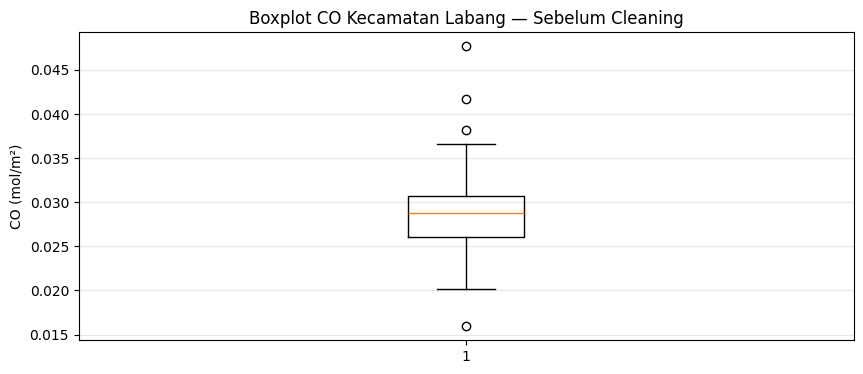

In [17]:
plt.figure(figsize=(10, 4))
plt.boxplot(dfCO["CO"].dropna())
plt.title("Boxplot CO Kecamatan Labang — Sebelum Cleaning")
plt.ylabel("CO (mol/m\u00b2)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 3.11 Membentuk kalender harian lengkap

Karena analisis bersifat time series harian, tanggal yang **tidak muncul sama sekali** pada data mentah (misalnya karena tidak ada lintasan satelit yang valid) juga harus dianggap sebagai *missing*, bukan hanya baris dengan nilai `NaN`. Oleh karena itu dibuat kalender penuh dari 31-08-2025 sampai 31-08-2026, lalu data di-*reindex* ke kalender tersebut — tanggal yang tidak ada datanya otomatis menjadi `NaN`.


In [18]:
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")

df_clean = (
    dfCO[["date", "CO"]]
    .drop_duplicates(subset="date")
    .set_index("date")
    .reindex(full_dates)
)
df_clean.index.name = "date"

print("Jumlah tanggal seharusnya (kalender penuh) :", len(full_dates))
print("Jumlah baris setelah reindex                :", len(df_clean))
print("Jumlah missing setelah reindex               :", int(df_clean['CO'].isna().sum()))

Jumlah tanggal seharusnya (kalender penuh) : 366
Jumlah baris setelah reindex                : 366
Jumlah missing setelah reindex               : 163


### 3.12 Imputasi missing value dan outlier

**Urutan proses:**

1. Nilai di luar batas IQR (dari poin 3.10) $\rightarrow$ ditandai `NaN`.
2. *Missing values* di **tengah** *time series* $\rightarrow$ diisi dengan **interpolasi linear berbasis waktu** (`interpolate(method="time")`).
3. *Missing values* yang tersisa di **ujung awal/akhir** (tidak bisa diinterpolasi karena tidak ada titik pembanding di salah satu sisi) $\rightarrow$ diisi dengan *forward fill* (`ffill`) lalu *backward fill* (`bfill`).
4. Validasi ulang $\rightarrow$ pastikan tidak ada `NaN` yang tersisa.

**Rumus interpolasi linear** — untuk mengisi titik kosong pada waktu $t$ yang berada di antara dua titik dikenal $(t_1, y_1)$ dan $(t_2, y_2)$:

$$y(t) = y_1 + \frac{t - t_1}{t_2 - t_1} \times (y_2 - y_1)$$

**Contoh perhitungan manual:**  
Andaikan $\text{NO}_2$ pada 10 Januari 2026 $= 3.0 \times 10^{-5}$ dan pada 12 Januari 2026 $= 5.0 \times 10^{-5}$, sedangkan 11 Januari 2026 kosong. Karena $t = 11 \text{ Jan}$ tepat di tengah $t_1 = 10 \text{ Jan}$ dan $t_2 = 12 \text{ Jan}$, maka $\frac{t - t_1}{t_2 - t_1} = \frac{1}{2}$, sehingga:

$$y(11\text{ Jan}) = 3.0 \times 10^{-5} + \frac{1}{2} \times \left(5.0 \times 10^{-5} - 3.0 \times 10^{-5}\right) = 4.0 \times 10^{-5}$$

Ini setara dengan rata-rata sederhana $\frac{y_1 + y_2}{2}$ karena titik kosong berada tepat di tengah selisih waktu satu hari. Jika jarak waktunya tidak simetris, bobot $\frac{t - t_1}{t_2 - t_1}$ akan menyesuaikan secara proporsional — inilah yang membedakan interpolasi *time-based* dari sekadar mengisi rata-rata global.


In [19]:
# Tandai outlier pada data kalender penuh sebagai NaN
clean_outlier_mask = (df_clean["CO"] < lower_bound) | (df_clean["CO"] > upper_bound)
n_outliers_in_full_series = int(clean_outlier_mask.sum())

df_clean.loc[clean_outlier_mask, "CO"] = np.nan
missing_before_imputation = int(df_clean["CO"].isna().sum())

print("Outlier yang ditandai ulang jadi NaN pada kalender penuh :", n_outliers_in_full_series)
print("Total missing sebelum imputasi (outlier + gap kalender)   :", missing_before_imputation)

# Interpolasi berbasis waktu untuk missing di tengah deret
df_clean["CO"] = df_clean["CO"].interpolate(method="time")

# Sisa missing di ujung awal/akhir (tidak bisa diinterpolasi) -> ffill lalu bfill
df_clean["CO"] = df_clean["CO"].ffill().bfill()

missing_after_imputation = int(df_clean["CO"].isna().sum())
print("Missing setelah imputasi                                  :", missing_after_imputation)

Outlier yang ditandai ulang jadi NaN pada kalender penuh : 4
Total missing sebelum imputasi (outlier + gap kalender)   : 167
Missing setelah imputasi                                  : 0


In [20]:
# BUKTI MANUAL INTERPOLASI TIME-BASED
# y(t) = y1 + ((t-t1)/(t2-t1)) * (y2-y1)

before_interp = df_clean["CO"].copy()
manual_interp_examples = []

for pos in range(len(before_interp)):
    if not pd.isna(before_interp.iloc[pos]):
        continue

    left = pos - 1
    while left >= 0 and pd.isna(before_interp.iloc[left]):
        left -= 1

    right = pos + 1
    while right < len(before_interp) and pd.isna(before_interp.iloc[right]):
        right += 1

    if left >= 0 and right < len(before_interp):
        t1 = before_interp.index[left]
        t2 = before_interp.index[right]
        t = before_interp.index[pos]
        y1 = float(before_interp.iloc[left])
        y2 = float(before_interp.iloc[right])

        weight = (t-t1).total_seconds() / (t2-t1).total_seconds()
        y_manual = y1 + weight*(y2-y1)

        manual_interp_examples.append(
            [t, t1, t2, y1, y2, weight, y_manual]
        )

print("Jumlah titik tengah yang dapat diverifikasi:", len(manual_interp_examples))

if manual_interp_examples:
    ex = pd.DataFrame(
        manual_interp_examples[:10],
        columns=["tanggal","t1","t2","y1","y2","bobot","hasil_manual"]
    )
    display(ex)

df_interp_check = before_interp.interpolate(method="time")

if manual_interp_examples:
    diffs = []
    for row in manual_interp_examples:
        tanggal = row[0]
        y_manual = row[-1]
        y_pandas = float(df_interp_check.loc[tanggal])
        diffs.append(abs(y_manual-y_pandas))

    print("Selisih maksimum manual vs pandas:", max(diffs))


Jumlah titik tengah yang dapat diverifikasi: 0


### 3.13 Validasi sebelum ekstraksi TSFEL

Sinyal dianggap layak diproses TSFEL hanya jika **seluruh** syarat berikut terpenuhi:

- jumlah observasi = 366 (sesuai kalender penuh);
- kolom `CO` bertipe numerik;
- tidak ada `NaN`;
- tidak ada `+inf` / `-inf`;
- tanggal terurut menaik (monotonic increasing).


In [21]:
df_final_signal = df_clean[["CO"]].copy()

checks = {
    "Tidak ada missing value"   : df_final_signal["CO"].isna().sum() == 0,
    "Tidak ada nilai +infinity" : np.isposinf(df_final_signal["CO"]).sum() == 0,
    "Tidak ada nilai -infinity" : np.isneginf(df_final_signal["CO"]).sum() == 0,
    "Kolom CO numerik"         : pd.api.types.is_numeric_dtype(df_final_signal["CO"]),
    "Jumlah tanggal lengkap"    : len(df_final_signal) == len(full_dates),
    "Tanggal terurut menaik"    : df_final_signal.index.is_monotonic_increasing,
}

for name, result in checks.items():
    print(f"[{'OK' if result else 'GAGAL'}] {name}")

if all(checks.values()):
    print("\nVALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.")
else:
    raise ValueError("VALIDASI GAGAL -> periksa kembali tahap deteksi outlier/imputasi sebelum lanjut.")

[OK] Tidak ada missing value
[OK] Tidak ada nilai +infinity
[OK] Tidak ada nilai -infinity
[OK] Kolom CO numerik
[OK] Jumlah tanggal lengkap
[OK] Tanggal terurut menaik

VALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.


In [22]:
df_final_signal.reset_index().to_csv("CO_Labang_clean.csv", index=False)

print("File hasil cleaning tersimpan: CO_Labang_clean.csv")
display(df_final_signal.head())
display(df_final_signal.tail())

colab_files.download("CO_Labang_clean.csv")
print("Unduhan dimulai: CO_Labang_clean.csv (data setelah outlier & missing ditangani).")

File hasil cleaning tersimpan: CO_Labang_clean.csv


,CO
date,
2025-08-31,0.0275496
2025-09-01,0.0236686
2025-09-02,0.0256338
2025-09-03,0.0220901
2025-09-04,0.026039


,CO
date,
2026-08-27,0.0281181
2026-08-28,0.0357047
2026-08-29,0.0365699
2026-08-30,0.0335374
2026-08-31,0.0335374


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: CO_Labang_clean.csv (data setelah outlier & missing ditangani).


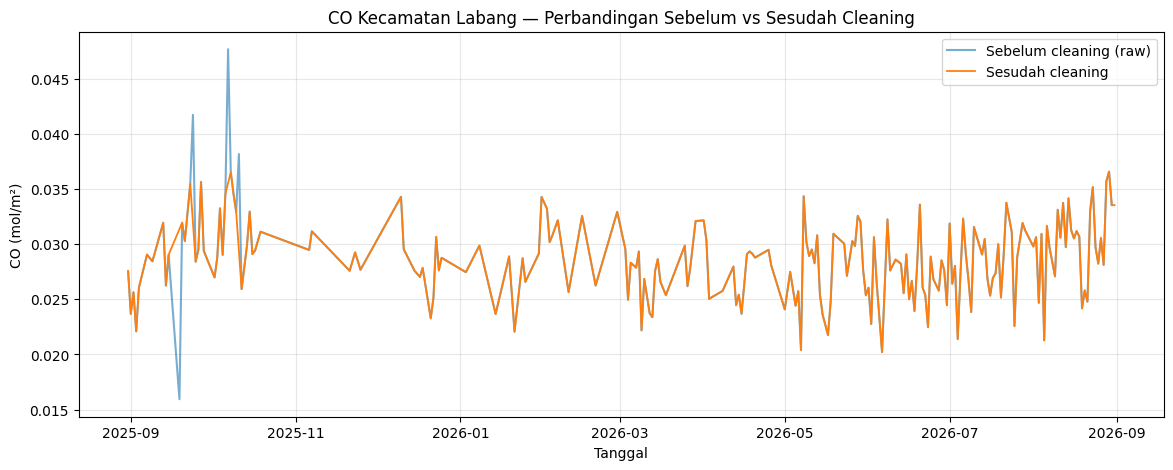

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(dfCO["date"], dfCO["CO"], label="Sebelum cleaning (raw)", alpha=0.6)
plt.plot(df_final_signal.index, df_final_signal["CO"], label="Sesudah cleaning", linewidth=1.3)
plt.title("CO Kecamatan Labang — Perbandingan Sebelum vs Sesudah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("CO (mol/m\u00b2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Modeling — Ekstraksi 68 Fitur dengan TSFEL

### 4.1 Apa itu TSFEL?

**TSFEL** (*Time Series Feature Extraction Library*) adalah pustaka Python yang menyediakan puluhan fungsi siap pakai untuk mengekstrak fitur numerik dari sebuah sinyal time series — mencakup domain **statistik**, **temporal**, **spektral (frekuensi)**, dan **fraktal/kompleksitas**. Setiap fungsi menerima array 1 dimensi (sinyal) dan mengembalikan satu (atau beberapa) nilai ringkasan.

### 4.2 Mengapa hasilnya hanya 1 baris?

**seluruh 366 nilai CO harian sebagai satu sinyal time series tunggal**, bukan 366 baris data independen. Oleh karena itu:

$$
\underbrace{366 \text{ nilai harian}}_{\text{1 sinyal}} \;\xrightarrow{68 \text{ fungsi TSFEL}}\; \underbrace{68 \text{ nilai ringkasan}}_{\text{1 baris} \times \text{68 kolom}}
$$

Parameter `fs` (frekuensi sampling) diset **`fs = 1`** karena satuan waktu antar-observasi adalah **1 hari**, sehingga "frekuensi" pada fitur-fitur spektral (misalnya `spectral_centroid`, `max_frequency`) diinterpretasikan dalam satuan **siklus per hari**, bukan Hz fisik biasa.



In [24]:
import tsfel.feature_extraction.features as tsfel_features

# Gunakan sinyal final yang SUDAH dibersihkan dan divalidasi.
# Tidak dilakukan IQR/interpolasi kedua kali di tahap ekstraksi.

df = df_final_signal.reset_index().copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target_pollutant = "CO"
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors="coerce")

if df[target_pollutant].isna().any():
    raise ValueError("Masih ada NaN pada sinyal final.")
if np.isinf(df[target_pollutant].to_numpy(dtype=float)).any():
    raise ValueError("Masih ada infinity pada sinyal final.")

fs = 1
signal_1d = df[target_pollutant].astype(float).to_numpy()

print("=== SINYAL CO FINAL YANG MASUK KE TSFEL ===")
print("Jumlah observasi :", len(signal_1d))
print("Tanggal awal     :", df["date"].min())
print("Tanggal akhir    :", df["date"].max())
print("Mean CO          :", signal_1d.mean())
print("Min CO           :", signal_1d.min())
print("Max CO           :", signal_1d.max())

FEATURE_LIST = '''abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross'''.split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))
assert len(FEATURE_LIST) == 68

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float).ravel()
        finite = arr[np.isfinite(arr)]
        if len(finite) == 0:
            return np.nan
        return float(np.mean(finite))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(
    f"Berhasil! Jumlah fitur yang dihasilkan untuk "
    f"{target_pollutant}: {extracted_features_final.shape[1]}"
)

extracted_features_final.to_csv(
    f"{target_pollutant}_Labang_TSFEL.csv",
    index=False
)


=== SINYAL CO FINAL YANG MASUK KE TSFEL ===
Jumlah observasi : 366
Tanggal awal     : 2025-08-31 00:00:00
Tanggal akhir    : 2026-08-31 00:00:00
Mean CO          : 0.028686346150323946
Min CO           : 0.0202053869143128
Max CO           : 0.0365699362009763
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


### 4.3 Validasi hasil ekstraksi

Memastikan output benar-benar berjumlah 68 kolom, nama & urutannya identik dengan `FEATURE_LIST`, serta tidak mengandung `NaN` maupun nilai tak-hingga.


In [26]:
expected_features = FEATURE_LIST

print("Shape output extracted_features_final :", extracted_features_final.shape)
print("Jumlah fitur yang diharapkan          :", len(expected_features))

same_order = list(extracted_features_final.columns) == expected_features
same_names = set(extracted_features_final.columns) == set(expected_features)

print("Nama fitur sama dengan FEATURE_LIST ? :", same_names)
print("Urutan fitur sama                    ? :", same_order)
print("Jumlah NaN pada output                :", int(extracted_features_final.isna().sum().sum()))
print("Jumlah nilai infinity pada output      :", int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()))

if extracted_features_final.shape[1] != 68:
    raise ValueError("Output BUKAN 68 fitur -- periksa FEATURE_LIST.")
if not same_order:
    raise ValueError("Nama atau urutan fitur berubah dari FEATURE_LIST.")
if extracted_features_final.isna().any().any():
    raise ValueError("Terdapat NaN pada output fitur.")
if np.isinf(extracted_features_final.to_numpy(dtype=float)).any():
    raise ValueError("Terdapat nilai infinity pada output fitur.")

print("\nVALIDASI TSFEL LULUS -- tepat 68 fitur.")

Shape output extracted_features_final : (1, 68)
Jumlah fitur yang diharapkan          : 68
Nama fitur sama dengan FEATURE_LIST ? : True
Urutan fitur sama                    ? : True
Jumlah NaN pada output                : 0
Jumlah nilai infinity pada output      : 0

VALIDASI TSFEL LULUS -- tepat 68 fitur.


In [27]:
x = np.asarray(signal_1d, dtype=float)
n = len(x)
t = np.arange(n, dtype=float)
xbar = np.mean(x)
diff = np.diff(x)

def percentile_linear_manual(data, p):
    data = np.sort(np.asarray(data, dtype=float))
    pos = (len(data)-1)*p
    lo = int(np.floor(pos))
    hi = int(np.ceil(pos))
    if lo == hi:
        return float(data[lo])
    return float(data[lo] + (pos-lo)*(data[hi]-data[lo]))

m2 = np.mean((x-xbar)**2)
m3 = np.mean((x-xbar)**3)
m4 = np.mean((x-xbar)**4)

manual_direct = {
    "calc_mean": np.mean(x),
    "calc_var": np.mean((x-xbar)**2),
    "calc_std": np.sqrt(np.mean((x-xbar)**2)),
    "calc_max": np.max(x),
    "calc_min": np.min(x),
    "calc_median": np.median(x),
    "mean_abs_deviation": np.mean(np.abs(x-xbar)),
    "median_abs_deviation": np.median(np.abs(x-np.median(x))),
    "interq_range": percentile_linear_manual(x,.75)-percentile_linear_manual(x,.25),
    "skewness": m3/(m2**1.5) if m2 else np.nan,
    "kurtosis": m4/(m2**2)-3 if m2 else np.nan,
    "abs_energy": np.sum(x**2),
    "rms": np.sqrt(np.mean(x**2)),
    "mean_diff": np.mean(diff),
    "mean_abs_diff": np.mean(np.abs(diff)),
    "median_diff": np.median(diff),
    "median_abs_diff": np.median(np.abs(diff)),
    "sum_abs_diff": np.sum(np.abs(diff)),
    "pk_pk_distance": np.max(x)-np.min(x),
    "slope": np.sum((t-t.mean())*(x-xbar))/np.sum((t-t.mean())**2),
    "zero_cross": np.sum((x[:-1]-xbar)*(x[1:]-xbar)<0),
}

if n > 1:
    manual_direct["autocorr"] = np.corrcoef(x[:-1],x[1:])[0,1]
else:
    manual_direct["autocorr"] = np.nan

X = np.fft.rfft(x)
P = np.abs(X)**2
freq = np.fft.rfftfreq(n,d=1.0)
Psum = P.sum()

manual_direct["average_power"] = P.mean()
manual_direct["max_power_spectrum"] = P.max()
manual_direct["max_frequency"] = freq[np.argmax(P)]
manual_direct["spectral_centroid"] = (freq@P)/Psum if Psum else np.nan

sc = manual_direct["spectral_centroid"]
manual_direct["spectral_spread"] = (
    np.sqrt(np.sum(P*(freq-sc)**2)/Psum) if Psum else np.nan
)

p = P/Psum if Psum else np.zeros_like(P)
p = p[p>0]
manual_direct["spectral_entropy"] = -np.sum(p*np.log2(p))

audit_rows = []
for feat,val in manual_direct.items():
    tsfel_val = float(extracted_features_final.loc[0,feat])
    audit_rows.append({
        "Fitur":feat,
        "Perhitungan manual":val,
        "TSFEL":tsfel_val,
        "Selisih absolut":abs(val-tsfel_val)
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.sort_values("Selisih absolut"))

print("Jumlah fitur yang diaudit manual secara numerik:",len(audit_df))
print("Selisih tidak otomatis berarti kesalahan; definisi/parameter internal")
print("TSFEL dapat berbeda dari formula ilustratif untuk beberapa fitur.")


,Fitur,Perhitungan manual,TSFEL,Selisih absolut
0,calc_mean,0.0286863,0.0286863,0
1,calc_var,8.34879e-06,8.34879e-06,0
2,calc_std,0.00288943,0.00288943,0
3,calc_max,0.0365699,0.0365699,0
4,calc_min,0.0202054,0.0202054,0
5,calc_median,0.0287905,0.0287905,0
6,mean_abs_deviation,0.00224885,0.00224885,0
7,median_abs_deviation,0.00178594,0.00178594,0
8,interq_range,0.00366264,0.00366264,0
9,skewness,-0.0981889,-0.0981889,0


Jumlah fitur yang diaudit manual secara numerik: 28
Selisih tidak otomatis berarti kesalahan; definisi/parameter internal
TSFEL dapat berbeda dari formula ilustratif untuk beberapa fitur.


In [28]:

x = np.asarray(signal_1d, dtype=float)
n = len(x)
xbar = np.mean(x)

manual = {}

#Statistical
manual["calc_mean"] = np.sum(x) / n
manual["calc_var"] = np.sum((x - xbar)**2) / n
manual["calc_std"] = np.sqrt(manual["calc_var"])
manual["calc_max"] = np.max(x)
manual["calc_min"] = np.min(x)
manual["calc_median"] = np.median(x)

manual["mean_abs_deviation"] = np.sum(np.abs(x - xbar)) / n
manual["median_abs_deviation"] = np.median(np.abs(x - manual["calc_median"]))

q1, q3 = np.percentile(x, [25, 75])
manual["interq_range"] = q3 - q1

m2 = np.mean((x - xbar)**2)
m3 = np.mean((x - xbar)**3)
m4 = np.mean((x - xbar)**4)
manual["skewness"] = m3 / (m2**1.5) if m2 != 0 else np.nan
manual["kurtosis"] = m4 / (m2**2) - 3 if m2 != 0 else np.nan

#Temporal
manual["abs_energy"] = np.sum(x**2)
manual["rms"] = np.sqrt(np.mean(x**2))

diff = np.diff(x)
manual["mean_diff"] = np.mean(diff)
manual["mean_abs_diff"] = np.mean(np.abs(diff))
manual["median_diff"] = np.median(diff)
manual["median_abs_diff"] = np.median(np.abs(diff))
manual["sum_abs_diff"] = np.sum(np.abs(diff))
manual["pk_pk_distance"] = np.max(x) - np.min(x)

# slope terhadap indeks waktu 0..n-1
t = np.arange(n, dtype=float)
manual["slope"] = np.sum((t - t.mean()) * (x - xbar)) / np.sum((t - t.mean())**2)

# autocorrelation lag-1
if n > 1 and np.std(x[:-1]) != 0 and np.std(x[1:]) != 0:
    manual["autocorr"] = np.corrcoef(x[:-1], x[1:])[0, 1]
else:
    manual["autocorr"] = np.nan

# zero crossing pada sinyal yang sudah dipusatkan terhadap mean
centered = x - xbar
manual["zero_cross"] = np.sum(centered[:-1] * centered[1:] < 0)

X = np.fft.rfft(x)
P = np.abs(X)**2
freq = np.fft.rfftfreq(n, d=1.0)  # fs = 1 observasi/hari

manual["average_power"] = np.mean(P)
manual["max_power_spectrum"] = np.max(P)
manual["max_frequency"] = freq[np.argmax(P)]
manual["spectral_centroid"] = (
    np.sum(freq * P) / np.sum(P) if np.sum(P) != 0 else np.nan
)

# spectral spread
sc = manual["spectral_centroid"]
manual["spectral_spread"] = (
    np.sqrt(np.sum(P * (freq - sc)**2) / np.sum(P))
    if np.sum(P) != 0 else np.nan
)

# spectral entropy
p = P / np.sum(P) if np.sum(P) != 0 else np.zeros_like(P)
p_nonzero = p[p > 0]
manual["spectral_entropy"] = -np.sum(p_nonzero * np.log2(p_nonzero))

try:
    import pywt
    coeffs = pywt.wavedec(x, wavelet="db1", mode="symmetric")
    w = np.concatenate([np.asarray(c, dtype=float).ravel() for c in coeffs])
    manual["wavelet_abs_mean"] = np.mean(np.abs(w))
    manual["wavelet_energy"] = np.sum(w**2)
    manual["wavelet_std"] = np.std(w)
    manual["wavelet_var"] = np.var(w)
    energies = np.array([np.sum(np.asarray(c, dtype=float)**2) for c in coeffs])
    pe = energies / energies.sum() if energies.sum() else energies
    pe = pe[pe > 0]
    manual["wavelet_entropy"] = -np.sum(pe * np.log2(pe))
except Exception:
    print("PyWavelets tidak tersedia; fitur wavelet manual dilewati.")

print(f"Jumlah observasi yang digunakan: {n}")
print("Contoh hasil perhitungan manual:")
manual_df = pd.DataFrame(
    {"Fitur": list(manual.keys()), "Nilai manual": list(manual.values())}
)
display(manual_df)

# Bandingkan dengan output TSFEL hanya jika nama fitur tersedia.
if "extracted_features_final" in globals():
    rows = []
    for feat, val in manual.items():
        if feat in extracted_features_final.columns and np.isfinite(val):
            tsfel_val = extracted_features_final.loc[0, feat]
            rows.append({
                "Fitur": feat,
                "Manual": val,
                "TSFEL": tsfel_val,
                "Selisih_abs": abs(val - tsfel_val)
            })
    if rows:
        comparison = pd.DataFrame(rows)
        display(comparison.sort_values("Selisih_abs"))
        print(
            "Catatan: perbedaan dapat muncul jika definisi/parameter internal "
            "TSFEL berbeda dari formula ilustratif manual, terutama untuk fitur "
            "yang memiliki beberapa varian implementasi."
        )


Jumlah observasi yang digunakan: 366
Contoh hasil perhitungan manual:


,Fitur,Nilai manual
0,calc_mean,0.0286863
1,calc_var,8.34879e-06
2,calc_std,0.00288943
3,calc_max,0.0365699
4,calc_min,0.0202054
5,calc_median,0.0287905
6,mean_abs_deviation,0.00224885
7,median_abs_deviation,0.00178594
8,interq_range,0.00366264
9,skewness,-0.0981889


,Fitur,Manual,TSFEL,Selisih_abs
0,calc_mean,0.0286863,0.0286863,0
1,calc_var,8.34879e-06,8.34879e-06,0
2,calc_std,0.00288943,0.00288943,0
3,calc_max,0.0365699,0.0365699,0
4,calc_min,0.0202054,0.0202054,0
5,calc_median,0.0287905,0.0287905,0
6,mean_abs_deviation,0.00224885,0.00224885,0
7,median_abs_deviation,0.00178594,0.00178594,0
8,interq_range,0.00366264,0.00366264,0
9,skewness,-0.0981889,-0.0981889,0


Catatan: perbedaan dapat muncul jika definisi/parameter internal TSFEL berbeda dari formula ilustratif manual, terutama untuk fitur yang memiliki beberapa varian implementasi.


In [29]:
DOMAIN_MAP = {
    "Statistical": [
        "ecdf", "ecdf_percentile", "ecdf_percentile_count", "ecdf_slope", "entropy",
        "hist_mode", "interq_range", "kurtosis", "calc_max", "calc_mean",
        "mean_abs_deviation", "calc_median", "median_abs_deviation", "calc_min",
        "skewness", "calc_std", "calc_var",
    ],
    "Temporal": [
        "abs_energy", "auc", "autocorr", "calc_centroid", "distance", "dfa",
        "higuchi_fractal_dimension", "hurst_exponent", "lempel_ziv",
        "maximum_fractal_length", "mean_abs_diff", "mean_diff", "median_abs_diff",
        "median_diff", "negative_turning", "positive_turning", "neighbourhood_peaks",
        "petrosian_fractal_dimension", "pk_pk_distance", "slope", "sum_abs_diff",
        "zero_cross", "rms", "mse",
    ],
    "Spectral": [
        "average_power", "fundamental_frequency", "human_range_energy", "lpcc", "mfcc",
        "max_power_spectrum", "max_frequency", "median_frequency", "power_bandwidth",
        "spectral_centroid", "spectral_decrease", "spectral_distance", "spectral_entropy",
        "spectral_kurtosis", "spectral_positive_turning", "spectral_roll_off",
        "spectral_roll_on", "spectral_skewness", "spectral_slope", "spectral_spread",
        "spectral_variation", "spectrogram_mean_coeff", "wavelet_abs_mean",
        "wavelet_energy", "wavelet_entropy", "wavelet_std", "wavelet_var",
    ],
}

# Validasi: setiap fitur pada FEATURE_LIST harus masuk tepat 1 domain, dan totalnya 68
all_mapped = [f for feats in DOMAIN_MAP.values() for f in feats]

missing_from_map = [f for f in FEATURE_LIST if f not in all_mapped]
extra_in_map = [f for f in all_mapped if f not in FEATURE_LIST]
duplicated_in_map = [f for f in set(all_mapped) if all_mapped.count(f) > 1]

print("Jumlah fitur per domain:")
for domain, feats in DOMAIN_MAP.items():
    print(f"  {domain:<12}: {len(feats)} fitur")
print(f"  {'TOTAL':<12}: {len(all_mapped)} fitur (harus = 68)")

print("\nFitur FEATURE_LIST yang belum terpetakan ke domain mana pun:", missing_from_map)
print("Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          :", extra_in_map)
print("Fitur yang tidak sengaja terdaftar di lebih dari satu domain   :", duplicated_in_map)

if not missing_from_map and not extra_in_map and not duplicated_in_map and len(all_mapped) == 68:
    print("\nPemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.")
else:
    raise ValueError("Pemetaan domain tidak konsisten dengan FEATURE_LIST -- periksa DOMAIN_MAP.")

# Tampilkan nilai hasil ekstraksi, dikelompokkan per domain
for domain, feats in DOMAIN_MAP.items():
    print(f"\n=== Domain {domain} ({len(feats)} fitur) ===")
    display(extracted_features_final[feats].T.rename(columns={0: "nilai"}))

Jumlah fitur per domain:
  Statistical : 17 fitur
  Temporal    : 24 fitur
  Spectral    : 27 fitur
  TOTAL       : 68 fitur (harus = 68)

Fitur FEATURE_LIST yang belum terpetakan ke domain mana pun: []
Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          : []
Fitur yang tidak sengaja terdaftar di lebih dari satu domain   : []

Pemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.

=== Domain Statistical (17 fitur) ===


,nilai
ecdf,0.0150273
ecdf_percentile,0.0285083
ecdf_percentile_count,182.5
ecdf_slope,147.087
entropy,0.999358
hist_mode,0.0292059
interq_range,0.00366264
kurtosis,0.176784
calc_max,0.0365699
calc_mean,0.0286863



=== Domain Temporal (24 fitur) ===


,nilai
abs_energy,0.304239
auc,10.4687
autocorr,3
calc_centroid,180.004
distance,365.001
dfa,1.02462
higuchi_fractal_dimension,1.91614
hurst_exponent,0.811968
lempel_ziv,0.185792
maximum_fractal_length,-0.065943



=== Domain Spectral (27 fitur) ===


,nilai
average_power,0.000833533
fundamental_frequency,0.00273224
human_range_energy,0
lpcc,0.911622
mfcc,18.3875
max_power_spectrum,34.8279
max_frequency,0.428962
median_frequency,0
power_bandwidth,0.39071
spectral_centroid,0.0843006


In [30]:
x = signal_1d.astype(float)
n = len(x)
xbar = x.mean()

# calc_mean
manual_mean = sum(x) / n

# calc_var, calc_std
manual_var = sum((v - manual_mean) ** 2 for v in x) / n
manual_std = np.sqrt(manual_var)

# abs_energy, rms
manual_abs_energy = sum(v * v for v in x)
manual_rms = np.sqrt(manual_abs_energy / n)

# mean_abs_diff, median_abs_diff
diffs_abs = [abs(x[i] - x[i - 1]) for i in range(1, n)]
manual_mean_abs_diff = sum(diffs_abs) / len(diffs_abs)
diffs_abs_sorted = sorted(diffs_abs)
m = len(diffs_abs_sorted)
manual_median_abs_diff = (diffs_abs_sorted[m // 2] if m % 2 == 1
                           else (diffs_abs_sorted[m // 2 - 1] + diffs_abs_sorted[m // 2]) / 2)

# pk_pk_distance
manual_pk_pk = x.max() - x.min()

# zero_cross
centered = x - manual_mean
manual_zero_cross = sum(1 for i in range(1, n) if centered[i - 1] * centered[i] < 0)

# skewness & kurtosis (populasi)
m2 = sum((v - manual_mean) ** 2 for v in x) / n
m3 = sum((v - manual_mean) ** 3 for v in x) / n
m4 = sum((v - manual_mean) ** 4 for v in x) / n
manual_skewness = m3 / (m2 ** 1.5)
manual_kurtosis = m4 / (m2 ** 2) - 3.0

#slope: regresi linear terhadap indeks waktu t = 0..n-1
t = np.arange(n)
t_bar = t.mean()
num = sum((t[i] - t_bar) * (x[i] - manual_mean) for i in range(n))
den = sum((t[i] - t_bar) ** 2 for i in range(n))
manual_slope = num / den

# autocorr lag-1 (korelasi Pearson x[i] vs x[i-1])
x1 = x[:-1]
x2 = x[1:]
x1bar, x2bar = x1.mean(), x2.mean()
cov12 = sum((x1[i] - x1bar) * (x2[i] - x2bar) for i in range(len(x1)))
std1 = np.sqrt(sum((v - x1bar) ** 2 for v in x1))
std2 = np.sqrt(sum((v - x2bar) ** 2 for v in x2))
manual_autocorr = cov12 / (std1 * std2)

manual_results = {
    "calc_mean": manual_mean,
    "calc_var": manual_var,
    "calc_std": manual_std,
    "abs_energy": manual_abs_energy,
    "rms": manual_rms,
    "mean_abs_diff": manual_mean_abs_diff,
    "median_abs_diff": manual_median_abs_diff,
    "pk_pk_distance": manual_pk_pk,
    "zero_cross": manual_zero_cross,
    "skewness": manual_skewness,
    "kurtosis": manual_kurtosis,
    "slope": manual_slope,
    "autocorr": manual_autocorr,
}

print(f"{'Fitur':<18}{'Manual':>18}{'TSFEL':>18}{'Selisih absolut':>20}")
print("-" * 74)
for feat, manual_val in manual_results.items():
    tsfel_val = extracted_features_final.loc[0, feat]
    selisih = abs(manual_val - tsfel_val)
    print(f"{feat:<18}{manual_val:>18.6g}{tsfel_val:>18.6g}{selisih:>20.3g}")

print("\nCatatan: selisih yang sangat kecil (mendekati 0, misal < 1e-6) menandakan")
print("rumus manual konsisten dengan implementasi internal TSFEL. Jika ada selisih")
print("relatif lebih besar, hal ini umumnya disebabkan perbedaan pembagi (populasi vs")
print("sampel) atau definisi turunan (mis. excess vs non-excess kurtosis) pada versi TSFEL yang dipakai.")

Fitur                         Manual             TSFEL     Selisih absolut
--------------------------------------------------------------------------
calc_mean                  0.0286863         0.0286863            2.78e-17
calc_var                 8.34879e-06       8.34879e-06            3.39e-21
calc_std                  0.00288943        0.00288943            4.34e-19
abs_energy                  0.304239          0.304239            4.44e-16
rms                        0.0288315         0.0288315            2.08e-17
mean_abs_diff             0.00181622        0.00181622            1.52e-18
median_abs_diff           0.00100459        0.00100459                   0
pk_pk_distance             0.0163645         0.0163645                   0
zero_cross                        81                 0                  81
skewness                  -0.0981889        -0.0981889            2.87e-14
kurtosis                    0.176784          0.176784            3.55e-15
slope                   -

In [31]:
# Contoh perhitungan manual CO dengan 5 angka sederhana
contoh_co = [2.0, 4.0, 4.0, 5.0, 7.0]
n_contoh = len(contoh_co)

mean_contoh = sum(contoh_co) / n_contoh
urut_contoh = sorted(contoh_co)
median_contoh = urut_contoh[n_contoh // 2]
var_pop_contoh = sum((v - mean_contoh)**2 for v in contoh_co) / n_contoh
std_pop_contoh = np.sqrt(var_pop_contoh)
energy_contoh = sum(v**2 for v in contoh_co)
rms_contoh = np.sqrt(energy_contoh / n_contoh)

diff_contoh = [contoh_co[i] - contoh_co[i-1] for i in range(1, n_contoh)]
abs_diff_contoh = [abs(d) for d in diff_contoh]

print("=== CONTOH PERHITUNGAN MANUAL CO ===")
print("Data CO :", contoh_co)
print(f"Mean    : {mean_contoh:.4f}")
print(f"Median  : {median_contoh:.4f}")
print(f"Variance populasi : {var_pop_contoh:.4f}")
print(f"Std. deviasi populasi : {std_pop_contoh:.4f}")
print(f"Minimum : {min(contoh_co):.4f}")
print(f"Maksimum: {max(contoh_co):.4f}")
print(f"Abs Energy: {energy_contoh:.4f}")
print(f"RMS: {rms_contoh:.4f}")
print(f"Mean absolute difference: {sum(abs_diff_contoh)/len(abs_diff_contoh):.4f}")
print(f"Sum absolute difference : {sum(abs_diff_contoh):.4f}")

# Slope regresi terhadap t = 0,1,2,3,4
t_contoh = list(range(n_contoh))
sum_t = sum(t_contoh)
sum_x = sum(contoh_co)
sum_t2 = sum(t*t for t in t_contoh)
sum_tx = sum(t_contoh[i]*contoh_co[i] for i in range(n_contoh))
slope_contoh = (n_contoh*sum_tx - sum_t*sum_x) / (n_contoh*sum_t2 - sum_t**2)
print(f"Slope: {slope_contoh:.4f}")

# IQR dengan NumPy untuk menunjukkan langkah kuartil
q1_contoh, q3_contoh = np.percentile(contoh_co, [25, 75])
iqr_contoh = q3_contoh - q1_contoh
lb_contoh = q1_contoh - 1.5*iqr_contoh
ub_contoh = q3_contoh + 1.5*iqr_contoh
print(f"Q1={q1_contoh:.4f}, Q3={q3_contoh:.4f}, IQR={iqr_contoh:.4f}")
print(f"Lower Bound={lb_contoh:.4f}, Upper Bound={ub_contoh:.4f}")


=== CONTOH PERHITUNGAN MANUAL CO ===
Data CO : [2.0, 4.0, 4.0, 5.0, 7.0]
Mean    : 4.4000
Median  : 4.0000
Variance populasi : 2.6400
Std. deviasi populasi : 1.6248
Minimum : 2.0000
Maksimum: 7.0000
Abs Energy: 110.0000
RMS: 4.6904
Mean absolute difference: 1.2500
Sum absolute difference : 5.0000
Slope: 1.1000
Q1=4.0000, Q3=5.0000, IQR=1.0000
Lower Bound=2.5000, Upper Bound=6.5000


## 4.4 Perhitungan manual CO dengan contoh angka sederhana

Bagian ini memberikan contoh hitung manual yang **khusus untuk CO** agar alur perhitungannya mudah dipahami sebelum hasil dihitung dari seluruh observasi.

Misalkan lima observasi CO yang sudah bersih adalah:

$$x = [2,\ 4,\ 4,\ 5,\ 7]$$

### 4.4.1 Mean

$$
\bar{x} = \frac{2+4+4+5+7}{5}
= \frac{22}{5}
= 4.4
$$

### 4.4.2 Variance populasi dan standar deviasi

Hitung selisih terhadap mean:

| $x_i$ | $x_i-4.4$ | $(x_i-4.4)^2$ |
|---:|---:|---:|
| 2 | -2.4 | 5.76 |
| 4 | -0.4 | 0.16 |
| 4 | -0.4 | 0.16 |
| 5 | 0.6 | 0.36 |
| 7 | 2.6 | 6.76 |
| **Jumlah** | | **13.20** |

Variance populasi:

$$
\sigma^2 = \frac{13.20}{5}=2.64
$$

Standar deviasi:

$$
\sigma = \sqrt{2.64}\approx1.625
$$

> Pada pemeriksaan statistik awal notebook, `pandas.var()` menggunakan **sample variance** (`ddof=1`). Pada verifikasi beberapa fitur TSFEL, rumus populasi dengan pembagi $n$ digunakan jika sesuai definisi fitur. Perbedaan pembagi ini harus diperhatikan ketika membandingkan hasil manual.

### 4.4.3 Median, minimum, maksimum, dan IQR

Data sudah terurut: $[2,4,4,5,7]$.

- Median = **4**
- Minimum = **2**
- Maksimum = **7**

Dengan definisi kuartil yang digunakan perangkat lunak, $Q_1$ dan $Q_3$ dihitung dari data terurut, kemudian:

$$
IQR=Q_3-Q_1
$$

dan batas outlier:

$$
LB=Q_1-1.5(IQR),\
UB=Q_3+1.5(IQR)
$$

### 4.4.4 Energi absolut dan RMS

$$
E=2^2+4^2+4^2+5^2+7^2
=4+16+16+25+49=110
$$

$$
RMS=\sqrt{\frac{110}{5}}=\sqrt{22}\approx4.690
$$

### 4.4.5 Perubahan antarhari

Selisih absolut:

$$
|4-2|=2,\quad |4-4|=0,\quad |5-4|=1,\quad |7-5|=2
$$

Sehingga:

$$
\text{mean\_abs\_diff}
=\frac{2+0+1+2}{4}=1.25
$$

dan:

$$
\text{sum\_abs\_diff}=2+0+1+2=5
$$

### 4.4.6 Slope/tren sederhana

Jika indeks waktu adalah $t=[0,1,2,3,4]$, slope regresi linear dihitung dengan:

$$
b=
\frac{n\sum tx-(\sum t)(\sum x)}
{n\sum t^2-(\sum t)^2}
$$

Untuk contoh ini:

- $n=5$
- $\sum t=10$
- $\sum x=22$
- $\sum t^2=30$
- $\sum tx=44$

Maka:

$$
b=
\frac{5(44)-10(22)}
{5(30)-10^2}
=
\frac{220-220}{150-100}=0
$$

Contoh ini menghasilkan slope 0 karena nilai contoh dibuat agar tidak menunjukkan tren linear bersih. **Pada data CO Labang yang sebenarnya, nilai slope dihitung dari seluruh 366 observasi setelah cleaning.**

### 4.4.7 Contoh spectral centroid

Misalkan hasil FFT sederhana menghasilkan:

| Frekuensi $f$ (siklus/hari) | Power $P(f)$ |
|---:|---:|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |

Total power:

$$
\sum P=12
$$

Spectral centroid:

$$
SC=
\frac{(1)(2)+(2)(4)+(3)(6)}{12}
=
\frac{28}{12}
\approx2.33
$$

Artinya, pusat distribusi energi spektrum contoh berada sekitar **2.33 siklus per hari**. Ini adalah contoh matematis; interpretasi fisik pola atmosfer harus mempertimbangkan sampling harian, panjang deret, dan definisi fitur.

## 5. Evaluation

Evaluasi dilakukan pada tiga aspek utama untuk memastikan seluruh kriteria keberhasilan (Bagian 1.4) terpenuhi sebelum data dianggap siap untuk tahap Deployment.

### 5.1 Kualitas data time series
- periode lengkap 366 hari (31-08-2025 s.d. 31-08-2026);
- tanggal terurut menaik;
- kolom `CO` numerik;
- missing value setelah imputasi = 0;
- nilai infinity = 0.

### 5.2 Penanganan outlier
- $Q_1$, $Q_3$, dan $\text{IQR}$ terdokumentasi secara eksplisit;
- Batas bawah & batas atas terdokumentasi;
- Jumlah *outlier* yang terdeteksi tercatat;
- Seluruh *outlier* ditangani (diimputasi) sebelum ekstraksi fitur.

> **Catatan konseptual:** outlier secara statistik tidak selalu berarti kesalahan pengukuran — bisa jadi representasi peristiwa nyata (misalnya lonjakan aktivitas kendaraan).

### 5.3 Output TSFEL
- tepat 68 fitur;
- nama dan urutan kolom identik dengan `FEATURE_LIST`;
- tidak ada `NaN`;
- tidak ada nilai infinity.



### 5.4 Interpretasi khusus hasil CO

- **Mean/median:** tingkat pusat CO selama periode.
- **Std/variance/MAD/IQR:** seberapa besar penyebaran nilai CO.
- **Min/max:** nilai terendah dan tertinggi pada periode.
- **Mean/median difference:** perubahan antarhari.
- **Slope:** kecenderungan linear CO terhadap waktu.
- **Autocorrelation:** hubungan nilai CO dengan nilai hari sebelumnya.
- **Spectral features:** pola energi berdasarkan frekuensi pada sampling harian.
- **Wavelet/fractal/complexity:** struktur lokal dan kompleksitas deret yang tidak cukup dijelaskan oleh mean saja.

Nilai fitur **tidak otomatis berarti "CO aman" atau "CO berbahaya"**. Fitur merupakan representasi numerik pola CO dan harus dibaca bersama periode pengamatan, proses agregasi satelit, cleaning, serta konteks lingkungan.


In [32]:
evaluation = pd.DataFrame({
    "Metrik": [
        "Periode mulai",
        "Periode akhir",
        "Jumlah hari (kalender penuh)",
        "Q1 (kuartil 25%)",
        "Q3 (kuartil 75%)",
        "IQR",
        "Batas bawah outlier",
        "Batas atas outlier",
        "Jumlah outlier terdeteksi",
        "Missing sebelum imputasi",
        "Missing sesudah imputasi",
        "Jumlah fitur TSFEL dihasilkan",
        "NaN pada output TSFEL",
        "Infinity pada output TSFEL",
    ],
    "Hasil": [
        str(full_dates.min().date()),
        str(full_dates.max().date()),
        len(full_dates),
        round(float(q1), 6),
        round(float(q3), 6),
        round(float(iqr), 6),
        round(float(lower_bound), 6),
        round(float(upper_bound), 6),
        n_outliers_in_full_series,
        missing_before_imputation,
        missing_after_imputation,
        extracted_features_final.shape[1],
        int(extracted_features_final.isna().sum().sum()),
        int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()),
    ]
})

display(evaluation)

evaluation_passed = (
    len(full_dates) == 366 and
    missing_after_imputation == 0 and
    extracted_features_final.shape[1] == 68 and
    extracted_features_final.isna().sum().sum() == 0 and
    np.isinf(extracted_features_final.to_numpy(dtype=float)).sum() == 0
)

print("\nEVALUASI AKHIR:", "LULUS -- siap ke tahap Deployment" if evaluation_passed else "PERIKSA KEMBALI")

,Metrik,Hasil
0,Periode mulai,2025-08-31
1,Periode akhir,2026-08-31
2,Jumlah hari (kalender penuh),366
3,Q1 (kuartil 25%),0.02685
4,Q3 (kuartil 75%),0.030512
5,IQR,0.004569
6,Batas bawah outlier,0.019241
7,Batas atas outlier,0.037516
8,Jumlah outlier terdeteksi,4
9,Missing sebelum imputasi,167



EVALUASI AKHIR: LULUS -- siap ke tahap Deployment


## 6. Deployment

### 6.1 File final: `CO_Labang_TSFEL.csv`

File ini adalah **satu-satunya** file yang dikumpulkan sebagai hasil ekstraksi fitur.


In [33]:
FINAL_CSV = "CO_Labang_TSFEL.csv"

check_csv = pd.read_csv(FINAL_CSV)

print("File          :", FINAL_CSV)
print("Shape         :", check_csv.shape)
print("Kolom pertama :", check_csv.columns[0])
print("Kolom terakhir:", check_csv.columns[-1])

if check_csv.shape != (1, 68):
    raise ValueError(f"Shape salah: {check_csv.shape}; seharusnya (1, 68). Periksa kembali Bagian 4.")

print("\nFile final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.")

File          : CO_Labang_TSFEL.csv
Shape         : (1, 68)
Kolom pertama : abs_energy
Kolom terakhir: zero_cross

File final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.


In [34]:
colab_files.download(FINAL_CSV)
print("Unduhan dimulai:", FINAL_CSV, "-- JANGAN diubah/di-edit setelah ini.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: CO_Labang_TSFEL.csv -- JANGAN diubah/di-edit setelah ini.
